### Dataset and Task Metadata

In [1]:
from data_foundry.schema import DatasetMetadata, PredictiveMLTaskMetadata

dataset_mold = DatasetMetadata(
    unique_name="early_learning_predictors",
    dataset_year="2023",
    domain_str="education",
    # Data Source
    dataset_source="Other",
    original_dataset_source_download_link="https://www.datafirst.uct.ac.za/dataportal/index.php/catalog/962",
    download_description="""
    mkdir -p local-data-warehouse/early_learning_predictors 
    Go to https://www.datafirst.uct.ac.za/dataportal/index.php/catalog/962/get-microdata., create an account, download the data files and move them to local-data-warehouse/early_learning_predictors. Next, run:
   
    unzip local-data-warehouse/early_learning_predictors/elom-tb5i-2016-2023-v1-csv.zip -d local-data-warehouse/early_learning_predictors
    mv local-data-warehouse/early_learning_predictors/elom-tb5i-2016-2023-v1-csv/* local-data-warehouse/early_learning_predictors 
    rm local-data-warehouse/early_learning_predictors/elom-tb5i-2016-2023-v1-csv.zip
    rm -r local-data-warehouse/early_learning_predictors/elom-tb5i-2016-2023-v1-csv

    
""",
    # References
    academic_reference_bibtex=r"""@dataset{DataDrive2030_2024_elom_thrivebyfive,
  author       = {{DataDrive2030}},
  title        = {ELOM and Thrive by Five Index 2016--2023, Merged Data},
  version      = {1},
  year         = {2024},
  address      = {Cape Town},
  publisher    = {DataDrive2030},
  note         = {[dataset]. Producer: DataDrive2030; Distributor: DataFirst},
  doi          = {10.25828/WG0D-Y909},
  url          = {https://doi.org/10.25828/WG0D-Y909}
}

""",
    academic_reference_bibtex_key="DataDrive2030_2024_elom_thrivebyfive",
    license="Creative Commons CC-BY (Attribution-only) License",
    data_tags=[],
    curation_comments="""

""",
)
task_mold = PredictiveMLTaskMetadata(
    target_column_name="child_total_elom",
    problem_type="regression",
    objective_metric_name="rmse",
    group_on="id_facility",
)

## Preprocessing

In [2]:
import pandas as pd
import numpy as np

'''
- The data is collected for predictive analytics to find major drivers of early learning outcomes. Nevertheless, predictive performance matters and the data could also be used for identifying at risk children.
- The data consists of different subsets that were collected at different times. Sometimes the target was even collected before the predictors. Although the data is collected over time, the task is cross-sectional. Therefore, we drop most date features, after checking whether relevant information was already extracted.
- We use a grouped split based on id_facility to reflect a potential deployment scenario where we want to predict for a new facility. Note that a date (year) is available, but the data collection is conducted per facility so we don't use a time-based split.
- The target score ELOM is continuous, but decisions are made based on cutoffs to identify at-risk children. We keep the task as regression, to maintain the most information.
- Note: The data consists of different age groups, for which the ELOM score is computed differently. While under these circumstances a multi-class target using the given cutoffs might be a valid choice, the age is given  as a feaature and therefore, we assume that a model can be expected to learn patterns for subgroups.  
- The data is collected from several sources, including direct assessments, teacher questionnaires, parent surveys and facility data. The data is collected by different enumerators across different facilities. The target is from a separate tool (see further information below). 
- We drop all columns which are components or alternative versions of the target, to avoid leakage.
- We drop all samples with a missing target.
- Due to most samples having missing values, we drop all "HOME LEARNING ENVIRONMENT DATA" features. This mostly aligns with the Zindi challenge, except that the features hle_ind, quintile_used, and ses_proxy were kept. We keep the latter two, because they are not missing for all samples and are derived from other; not-HLE features.
- We drop all features with 100% missing values and one unique value.
- We drop all indicator columns.
- We drop some repeated columns, such as age_group_label.
- Because all features could generally be available at prediction time, even if would not be ideal effort-wise, we keep all features that don't leak the target or are otherwise problematic. 
- We transform all date columns to datetime.
- Additional description of the target: The ELOM 4 & 5 Years Assessment Tool measures whether preschool children are on track for their age in key areas of development. It is a standardised tool that measures performance across five key developmental domains for children aged 50 to 59 months and 60 to 69 months. The scoring assesses a child in 23 items, across five domains, namely: gross motor development, fine motor development, emergent numeracy and mathematics, cognition and executive functioning, and emergent literacy and language. These five domains form part of the direct assessment. 

- Note: We keep some features that were not in the zindi challenge, such as the teacher and parent questionnaires, because they are potentially predictive and could be available at prediction time. Moreover, some columns present in the zindi challenge (like latitude and longitude) are not available.
- Note: The data consists of a few subsets with partially distinct features collected. This might not represent a real task, but we don't know for sure, so we keeo all samples.
- Note: The enumerator_id is a control variable of the data collection rather than a factor that should be used for prediction. However, it is predictive and explains noise in the target, so we keep it as a feature.
- Note: There are strong patterns of missingness within the data, due to different uses of various tools and measurements across subgroups

- Anomaly: Many missing values
- Anomaly: This is a highly underspecified task, leaving a lot of data cleaning to the user/model.

'''

df = pd.read_csv(dataset_mold.path / "elom-tb5i-2016-2023-v1.csv", low_memory=False)
df = df.loc[~df["child_total_elom"].isna()]

# df = df[~df.child_id.isna()]
# df = df[~df.child_date.isna()]
# df = df.loc[:,df.isna().mean()!=1]

date_cols = ["child_date", "child_dob", "child_enrolment_date", "obs_date", "pqa_date", "pra_date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%d%b%Y", errors="coerce")

leaky_cols = [col for col in df.columns if "result" in col]
leaky_cols += [col for col in df.columns if "domain" in col]
leaky_cols += [col for col in df.columns if "child_score" in col]
leaky_cols += [col for col in df.columns if "child_total_elom_w2" in col]
leaky_cols += [col for col in df.columns if "_w2" in col]
leaky_cols += [col for col in df.columns if "_sef" in col] # other test, but also a time-consuming child assessment like ELOM
leaky_cols += ["child_total_elom_cuts", "duration_elom", "duration_elom_sef", "duration_elom_hle", "child_sample_wgt"]
leaky_cols += ["id_cluster_original"] # leaks with school-based split
leaky_cols += ['child_observe_total','child_observe_attentive', 'child_observe_concentrated', 'child_observe_diligent', 'child_observe_interested'] # Unsure but likely leak the target
leaky_cols += ['data_year', 'language_assessment'] # Also collected with the target
df = df.drop(columns=leaky_cols)

indicator_cols = ['child_id', 'id_enumerator', 'id_enumerator_hle', "id_prov_best", "audit_ind", "id_ward_best",
                  "child_conditions", "calc_test_hour", "teacher_gender", "count_aftercare", "saspri_datazone_quintile",
                  'id_dc_best', 'id_enumerator_hle','id_facility_hle','id_mn_best','id_prov_best','id_team','id_ward_best',
                  "data_source", 
                  'sef_ind', 'pra_ind'

                  ]
df = df.drop(columns=indicator_cols)

hle_cols = [col for col in df.columns if "hle_" in col or "_hle" in col]
df = df.drop(columns=hle_cols)

df = df.loc[:, df.isna().mean() < 1]
df = df.loc[:, df.nunique() > 1]

# Drop dates
date_cols = ['child_date', 'child_enrolment_date', 'obs_date', 'pqa_date', 'pra_date', 'pri_date', 'teacher_date']
df = df.drop(columns=date_cols)

# Repeated cols
repeated_cols = ["age_group_label"]
df = df.drop(columns=repeated_cols)

print("Loaded data shape:", df.shape)

Loaded data shape: (18874, 745)


In [3]:
print(f"Pri features: {len([col for col in df.columns if "pri_" in col or "_pri" in col])}")
print(f"Pra features: {len([col for col in df.columns if "pra_" in col or "_pra" in col])}")
print(f"Learning Programme Quality features: {len([col for col in df.columns if "pqa_" in col or "_pqa" in col])}")
print(f"Observation features: {len([col for col in df.columns if "obs_" in col or "_obs" in col])}")
print(f"Child features: {len([col for col in df.columns if "child_" in col or "_child" in col])}")
print(f"Teacher features: {len([col for col in df.columns if "teacher_" in col or "_teacher" in col])}")
print(f"Count per facility features: {len([col for col in df.columns if "count_" in col])}")
print(f"Other features: {len(df.columns) - sum([len([col for col in df.columns if prefix in col]) for prefix in ['pri_', 'pra_', 'pqa_', 'teacher_', 'obs_', 'child_', 'count_']])}")


Pri features: 258
Pra features: 149
Learning Programme Quality features: 35
Observation features: 161
Child features: 25
Teacher features: 22
Count per facility features: 74
Other features: 41


In [4]:
zindi_train = pd.read_csv("zindi_train.csv", low_memory=False)

# Matching the Zindi train set, to check whether we have the same data after dropping the columns
intersect_cols = list(set(df.columns).intersection(set(zindi_train.columns)))
print(f"{len(intersect_cols)} columns in common with Zindi train set.")

# New columns that are not in the Zindi train set, but are from a data subset collected independently of the target. start with pra_, pqa_, pri_, or obs_ )
pra_pqa_pri_obs_cols = [i for i in df.columns if i not in intersect_cols and ("pra_" in i or "pqa_" in i or "pri_" in i or "obs_" in i)]
print(f"{len(pra_pqa_pri_obs_cols)} columns are new and from  pra_, pqa_, pri_, or obs_ feature subsets.")

other_cols = [i for i in df.columns if i not in intersect_cols+pra_pqa_pri_obs_cols]
print(f"Remaining {len(other_cols)} columns that were not in the zindi challenge: {other_cols}")

print(f"Columns that are in the Zindi train set but not in our data: {[i for i in zindi_train.columns if i not in intersect_cols]}")

576 columns in common with Zindi train set.
136 columns are new and from  pra_, pqa_, pri_, or obs_ feature subsets.
Remaining 33 columns that were not in the zindi challenge: ['child_total_elom', 'child_has_sibling', 'child_spectacles', 'count_assistants', 'count_staff_cat_educator', 'count_staff_managers', 'count_staff_unpaid', 'count_staff_unpaid_assistants', 'count_staff_unpaid_cooks', 'count_staff_unpaid_maintenance', 'count_staff_unpaid_managers', 'count_staff_unpaid_practitioners', 'count_staff_unpaid_support', 'facility_hours', 'facility_size', 'gr_1_tt', 'gr_c1', 'gr_c2', 'gr_c3', 'gr_ecd', 'gr_r', 'library_access', 'position_other', 'position_other_reason', 'programme', 'programme_exposure', 'rating', 'sanitation_educators_1', 'sanitation_educators_2', 'sanitation_educators_3', 'teacher_age', 'teacher_familiarity_with_child', 'teacher_timechild']
Columns that are in the Zindi train set but not in our data: ['child_id', 'data_year', 'child_date', 'child_enrolment_date', 'child

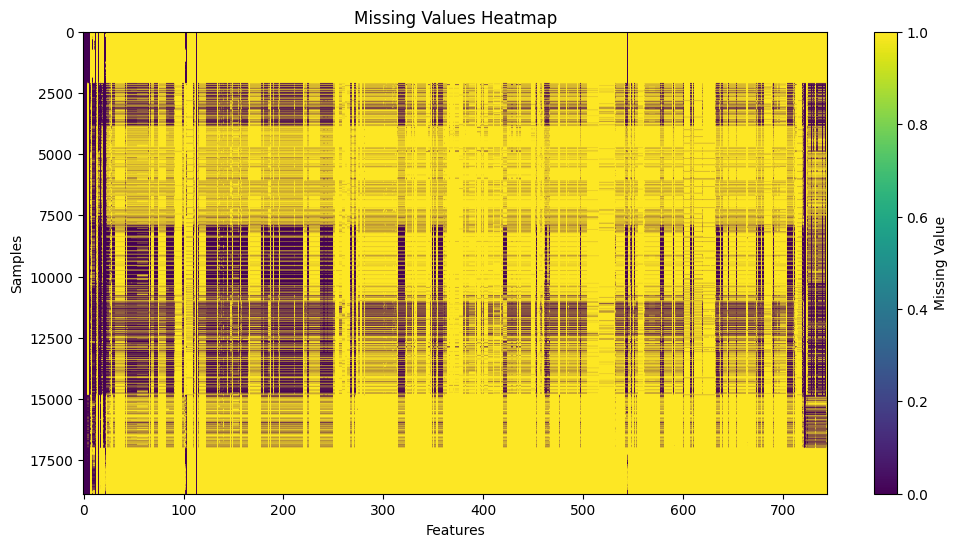

In [5]:
# The data has many missing values, but they are not missing at random.
import matplotlib.pyplot as plt
# Missing value heatmap
plt.figure(figsize=(12, 6))
plt.imshow(df.isna(), aspect='auto', cmap='viridis')
plt.colorbar(label='Missing Value')
plt.title('Missing Values Heatmap')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.show()

In [6]:
# Use if needed to get see all cols of pandas dataframes
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
df.head()

,child_dob,child_gender,child_age,child_age_group,child_attendance,child_attends,child_total_elom,child_grant,child_has_sibling,child_height,child_zha,child_stunted,child_languages,child_months_enrolment,child_spectacles,child_years_in_programme,dc_best,language_match,mn_best,phase_natemis,pre_covid,prov_best,quintile,ward_best,certificate_register,certificate_registration_npo,certificate_registration_partial,certificate_registration_program,count_assistants,count_children_attendance,count_children_precovid,count_children_present,count_practitioners_age_0,count_practitioners_age_1,count_practitioners_age_2,count_practitioners_age_3,count_practitioners_age_4,count_practitioners_age_5,count_practitioners_age_6,count_practitioners_all,count_present_boys,count_present_girls,count_register_all,count_register_foreign,count_register_gender,count_register_gender_female,count_register_gender_male,count_register_gender_other,count_register_race,count_register_race_african,count_register_race_coloured,count_register_race_indian,count_register_race_other,count_register_race_white,count_register_year_2013,count_register_year_2014,count_register_year_2015,count_register_year_2016,count_register_year_2017,count_register_year_2018,count_register_year_2019,count_register_year_2020,count_register_year_2021,count_register_year_grader,count_register_year_school,count_staff_all,count_staff_cat_educator,count_staff_contract,count_staff_contract_permanent,count_staff_contract_substitute,count_staff_contract_temporary,count_staff_gender,count_staff_gender_female,count_staff_gender_male,count_staff_gender_other,count_staff_managers,count_staff_paid,count_staff_paid_assistants,count_staff_paid_cooks,count_staff_paid_maintenance,count_staff_paid_managers,count_staff_paid_practitioners,count_staff_paid_support,count_staff_qual_nqf4_5,count_staff_qual_nqf6_9,count_staff_qual_skills,count_staff_salary,count_staff_salary_paid,count_staff_salary_unpaid,count_staff_time,count_staff_time_full,count_staff_time_part,count_staff_unpaid,count_staff_unpaid_assistants,count_staff_unpaid_cooks,count_staff_unpaid_maintenance,count_staff_unpaid_managers,count_staff_unpaid_practitioners,count_staff_unpaid_support,count_toilets_adults,count_toilets_children,facility_hours,facility_size,facility_type,gr_1_tt,gr_c1,gr_c2,gr_c3,gr_ecd,gr_r,grade_r,health,healthother,id_facility,library_access,obs_access,obs_access_disability_0,obs_access_disability_1,obs_access_disability_2,obs_access_disability_3,obs_access_disability_4,obs_access_disability_5,obs_access_disability_6,obs_accessible,obs_area,obs_area_0,obs_area_1,obs_area_2,obs_area_3,obs_area_4,obs_area_5,obs_area_6,obs_area_7,obs_area_8,obs_booknumber,obs_books,obs_books_age,obs_building,obs_capture_toilets_total,obs_classrooms,obs_condition_equipment,obs_cooking_1,obs_cooking_2,obs_cooking_3,obs_cooking_4,obs_cooking_5,obs_cooking_6,obs_cooking_7,obs_cooking_census,obs_electricity_working,obs_equipment_0,obs_equipment_1,obs_equipment_2,obs_equipment_3,obs_equipment_4,obs_equipment_5,obs_fence,obs_fencing_play_area,obs_firstaid,obs_gate,obs_handwashing_0,obs_handwashing_1,obs_handwashing_2,obs_handwashing_3,obs_handwashing_97,obs_handwashing_friendly,obs_handwashingother,obs_hazard,obs_hazard_0,obs_hazard_1,obs_hazard_2,obs_hazard_3,obs_hazard_4,obs_hazard_5,obs_hazard_6,obs_hazard_7,obs_hazard_8,obs_hazard_97,obs_heating_1,obs_heating_2,obs_heating_3,obs_heating_4,obs_heating_5,obs_heating_6,obs_heating_7,obs_heating_8,obs_heating_census,obs_infrastructure,obs_lighting_1,obs_lighting_2,obs_lighting_3,obs_lighting_4,obs_lighting_5,obs_lighting_6,obs_lighting_8,obs_lighting_census,obs_material_display,obs_materials,obs_materials_0,obs_materials_1,obs_materials_10,obs_materials_11,obs_materials_12,obs_materials_13,obs_materials_14,obs_materials_15,obs_materials_16,obs_materials_17,obs_materials_18,obs_materials_19,obs_materials_2,obs_materials_20,obs_materials_3,obs_materials_4,obs_materials_5,obs_materials_6,obs_materials_

## Data Checks

In [7]:
from data_foundry import dataset_checks
df_head, summary, numeric_stats, cat_stats, target_df = dataset_checks.run_all_checks(
    data=df,
    classification=task_mold.is_classification,
    target_feature=task_mold.target_column_name,
    print_report=False, # In notebook...
)


#### Dataset Overview
Rows: 18,874
Columns: 745
Use sampling: False (sample size: 18,874)
Get row duplicates (staged, merged)...
Using top-10 columns for initial filtering: ['child_zha', 'id_facility', 'child_age', 'child_dob', 'obs_materials', 'child_height', 'teacher_duration', 'pri_expense_staff', 'pri_amount_funding_dsd', 'pri_amount_funding_fees']
Rows remaining as candidates after top-10 filter: 208 (of 18,874)

#### Duplicate Report
Total duplicate rows: 2 (0.01% of dataset)
Duplicate rows ignoring target: 31 (0.16% of dataset)
Get column duplicates...
Duplicate columns: 1 (0.13% of columns)
Duplicate column names:
  - certificate_registration_npo

Data quality checks completed.


In [8]:
# Sample Rows
df_head

,child_dob,child_gender,child_age,child_age_group,child_attendance,child_attends,child_total_elom,child_grant,child_has_sibling,child_height,child_zha,child_stunted,child_languages,child_months_enrolment,child_spectacles,child_years_in_programme,dc_best,language_match,mn_best,phase_natemis,pre_covid,prov_best,quintile,ward_best,certificate_register,certificate_registration_npo,certificate_registration_partial,certificate_registration_program,count_assistants,count_children_attendance,count_children_precovid,count_children_present,count_practitioners_age_0,count_practitioners_age_1,count_practitioners_age_2,count_practitioners_age_3,count_practitioners_age_4,count_practitioners_age_5,count_practitioners_age_6,count_practitioners_all,count_present_boys,count_present_girls,count_register_all,count_register_foreign,count_register_gender,count_register_gender_female,count_register_gender_male,count_register_gender_other,count_register_race,count_register_race_african,count_register_race_coloured,count_register_race_indian,count_register_race_other,count_register_race_white,count_register_year_2013,count_register_year_2014,count_register_year_2015,count_register_year_2016,count_register_year_2017,count_register_year_2018,count_register_year_2019,count_register_year_2020,count_register_year_2021,count_register_year_grader,count_register_year_school,count_staff_all,count_staff_cat_educator,count_staff_contract,count_staff_contract_permanent,count_staff_contract_substitute,count_staff_contract_temporary,count_staff_gender,count_staff_gender_female,count_staff_gender_male,count_staff_gender_other,count_staff_managers,count_staff_paid,count_staff_paid_assistants,count_staff_paid_cooks,count_staff_paid_maintenance,count_staff_paid_managers,count_staff_paid_practitioners,count_staff_paid_support,count_staff_qual_nqf4_5,count_staff_qual_nqf6_9,count_staff_qual_skills,count_staff_salary,count_staff_salary_paid,count_staff_salary_unpaid,count_staff_time,count_staff_time_full,count_staff_time_part,count_staff_unpaid,count_staff_unpaid_assistants,count_staff_unpaid_cooks,count_staff_unpaid_maintenance,count_staff_unpaid_managers,count_staff_unpaid_practitioners,count_staff_unpaid_support,count_toilets_adults,count_toilets_children,facility_hours,facility_size,facility_type,gr_1_tt,gr_c1,gr_c2,gr_c3,gr_ecd,gr_r,grade_r,health,healthother,id_facility,library_access,obs_access,obs_access_disability_0,obs_access_disability_1,obs_access_disability_2,obs_access_disability_3,obs_access_disability_4,obs_access_disability_5,obs_access_disability_6,obs_accessible,obs_area,obs_area_0,obs_area_1,obs_area_2,obs_area_3,obs_area_4,obs_area_5,obs_area_6,obs_area_7,obs_area_8,obs_booknumber,obs_books,obs_books_age,obs_building,obs_capture_toilets_total,obs_classrooms,obs_condition_equipment,obs_cooking_1,obs_cooking_2,obs_cooking_3,obs_cooking_4,obs_cooking_5,obs_cooking_6,obs_cooking_7,obs_cooking_census,obs_electricity_working,obs_equipment_0,obs_equipment_1,obs_equipment_2,obs_equipment_3,obs_equipment_4,obs_equipment_5,obs_fence,obs_fencing_play_area,obs_firstaid,obs_gate,obs_handwashing_0,obs_handwashing_1,obs_handwashing_2,obs_handwashing_3,obs_handwashing_97,obs_handwashing_friendly,obs_handwashingother,obs_hazard,obs_hazard_0,obs_hazard_1,obs_hazard_2,obs_hazard_3,obs_hazard_4,obs_hazard_5,obs_hazard_6,obs_hazard_7,obs_hazard_8,obs_hazard_97,obs_heating_1,obs_heating_2,obs_heating_3,obs_heating_4,obs_heating_5,obs_heating_6,obs_heating_7,obs_heating_8,obs_heating_census,obs_infrastructure,obs_lighting_1,obs_lighting_2,obs_lighting_3,obs_lighting_4,obs_lighting_5,obs_lighting_6,obs_lighting_8,obs_lighting_census,obs_material_display,obs_materials,obs_materials_0,obs_materials_1,obs_materials_10,obs_materials_11,obs_materials_12,obs_materials_13,obs_materials_14,obs_materials_15,obs_materials_16,obs_materials_17,obs_materials_18,obs_materials_19,obs_materials_2,obs_materials_20,obs_materials_3,obs_materials_4,obs_materials_5,obs_materials_6,obs_materials_

In [9]:
# Feature Summary
summary

,index,dtype,n_missing,pct_missing,n_unique,examples
0,child_dob,datetime64[ns],3394.0,17.98,1774.0,"2016-11-11 00:00:00, 2017-07-17 00:00:00, 2017-03-03 00:00:00, 2017-03-17 00:00:00, 2016-12-12 00:00:00, 2017-01-17 00:00:00, 2017-01-19 00:00:00, 2016-12-15 00:00:00, 2017-03-15 00:00:00, 2016-12-01 00:00:00"
1,pra_letcee_clubattendance,float64,18821.0,99.72,4.0,"9.0, 7.0, 2.0, 1.0"
2,pra_letcee_clubmeetings,float64,18821.0,99.72,3.0,"9.0, 2.0, 1.0"
3,pra_letcee_clubsupport,float64,18821.0,99.72,2.0,"4.0, 3.0"
4,pra_letcee_support_coach,float64,18821.0,99.72,3.0,"4.0, 3.0, 1.0"
5,pra_lesedi_support,float64,18811.0,99.67,2.0,"3.0, 4.0"
6,pra_lesedi_visits,float64,18811.0,99.67,2.0,"5.0, 3.0"
7,pra_measure_lshape_length_1,float64,18801.0,99.61,7.0,"6.0, 8.0, 5.0, 4.0, 10.0, 7.0, 3.0"
8,pra_measure_lshape_length_2,float64,18801.0,99.61,8.0,"4.0, 5.0, 8.0, 6.0, 3.0, 7.0, 13.0, 12.0"
9,pra_measure_lshape_width_1,float64,18801.0,99.61,6.0,"3.0, 4.0, 5.0, 6.0, 7.0, 8.0"


In [10]:
# Numeric Feature Statistics
numeric_stats

,count,mean,std,min,max
child_age,18874.0,58.218104,5.328107,49.00000,69.486656
child_attendance,5803.0,4.773565,0.707529,1.00000,7.000000
child_total_elom,18874.0,48.103786,15.584195,6.37000,99.590000
child_height,14244.0,106.624685,6.848996,0.00000,208.000000
child_zha,13511.0,-0.416681,1.104028,-5.96443,5.634917
child_months_enrolment,3733.0,20.244843,14.002012,0.00000,57.000000
quintile,17011.0,2.318970,1.238926,1.00000,5.000000
ward_best,8797.0,26.110265,28.514102,1.00000,130.000000
count_assistants,1084.0,5.664207,15.676077,0.00000,100.000000
count_children_attendance,7323.0,50.761983,35.547472,2.00000,250.000000


In [11]:
# Categorical Feature Statistics
cat_stats

value  \
column                           rank                                                                        
certificate_register             1                                                                    <NA>   
                                 2                                                                     Yes   
                                 3                                                       No, but it exists   
                                 4                                                          Does not exist   
certificate_registration_npo     1                                                                    <NA>   
                                 2                                                                     Yes   
                                 3                                                       No, but it exists   
                                 4                                                          Does not exist   
certificate_registration_partial 1                                                                    <NA>   
                                 2                                                                     Yes   
                                 3                                                       No, but it exists   
                                 4                                                          Does not exist   
certificate_registration_program 1                                                                    <NA>   
                                 2                                                                     Yes   
                                 3                                                       No, but it exists   
                                 4                                                          Does not exist   
child_age_group                  1                                                            50-59 Months   
                                 2                                                            60-69 Months   
child_attends                    1                                                                    <NA>   
                                 2                                                                     Yes   
                                 3                                                                      No   
                                 4                                                               Dont know   
child_dob                        1                                                                    <NA>   
                                 2                                                     2016-11-11 00:00:00   
                                 3                                                     2017-07-17 00:00:00   
                                 4                                                     2017-03-03 00:00:00   
                                 5                                                     2017-03-17 00:00:00   
child_gender                     1                                                                  Female   
                                 2                                                                    Male   
child_grant                      1                                                                    <NA>   
                                 2                                                                     Yes   
                                 3                                                                      No   
                                 4                                                                 Refusal   
                                 5                                                              Don't know   
child_has_sibling                1                                                                    <NA>   
                               

In [12]:
# Target Distribution
target_df

,y_missing_count,non_positive_pct,skew_y,skew_log,var_y,var_log,log_used,aic_exponential,aic_lognormal,dist_hint
0,0,0.0,0.14,-0.815,242.867,0.131,log,184361.2,13517662.4,exponential


## Task Curation

In [13]:
from data_foundry.curation_recommendations import get_recommended_splits_dimensions

n_repeats, n_splits, none_or_test_size = get_recommended_splits_dimensions(
    dataset=df,
    group_on=task_mold.group_on,
    time_on=task_mold.time_on,
)
print(f"Recommended splits: n_repeats={n_repeats}, n_splits={n_splits}, test_size={none_or_test_size}")

Providing recommendations based on number of groups (2541).
Recommended splits: n_repeats=10, n_splits=3, test_size=None


In [14]:
from data_foundry.schema import PredictiveMLSplitsMetadata
from data_foundry import curation_recommendations

# -- For Grouped Non-IID data
splits = curation_recommendations.get_recommended_grouped_splits(
    dataset=df,
    n_repeats=n_repeats,
    n_splits=n_splits,
    group_on=task_mold.group_on,
    test_size=none_or_test_size,
    stratify_on=task_mold.stratify_on,
)

for rep_idx, rep in enumerate(splits):
    for split in splits[rep]:
        
        train_idx = splits[rep][split][0]
        test_idx = splits[rep][split][1]
        print(f"Repeat {rep_idx} Split {split}")
        print(f"Train groups: {df.iloc[train_idx][task_mold.group_on].nunique()}, Test groups: {df.iloc[test_idx][task_mold.group_on].nunique()}")
        y_statistics = pd.DataFrame({"Train y-statistics": df.iloc[train_idx][task_mold.target_column_name].describe(), "Test y-statistics": df.iloc[test_idx][task_mold.target_column_name].describe()})
        print(y_statistics)

splits_mold = PredictiveMLSplitsMetadata(
    splits_comment="Default splits.",
    splits=splits,
)

Repeat 0 Split 0
Train groups: 1694, Test groups: 847
       Train y-statistics  Test y-statistics
count        12839.000000        6035.000000
mean            48.002883          48.318451
std             15.580985          15.590141
min              7.660000           6.370000
25%             36.665001          36.855000
50%             47.440000          47.880000
75%             59.050000          59.405000
max             99.590000          98.080000
Repeat 0 Split 1
Train groups: 1694, Test groups: 847
       Train y-statistics  Test y-statistics
count        12471.000000        6403.000000
mean            48.257234          47.804920
std             15.570128          15.608443
min              6.370000           8.770000
25%             36.940000          36.369999
50%             47.700000          47.240000
75%             59.375000          58.730000
max             98.080000          99.590000
Repeat 0 Split 2
Train groups: 1694, Test groups: 847
       Train y-statistics  T

## Export

In [15]:
from data_foundry.curation_container import CuratedContainer
curated_data = CuratedContainer(
    dataset=df,
    dataset_metadata=dataset_mold,
    task_metadata=task_mold,
    experiment_metadata=splits_mold,
 )
curated_data.save()
print(curated_data.uuid)
print(curated_data.checksum)

Calculating checksum for curated container...
019d4460-7c53-795e-aa20-a54c0ccd7807
7c3d215681b0ab5ab96876af177a8295b29a8f7fd32059f7ce049a7709ab7ca9
